# 06 — ResNet18 (Méthode B + augmentation avancée)

Version allégée du notebook :
- nouvelle structure `brain_tumor_mri`
- `WeightedRandomSampler`
- augmentation avancée
- early stopping
- sauvegarde du meilleur checkpoint selon **PRAUC**

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn, optim

from brain_tumor_mri.data.dataset import BrainMRIDataset
from brain_tumor_mri.data.transforms import get_train_transforms, get_eval_transforms
from brain_tumor_mri.data.loaders import make_loaders
from brain_tumor_mri.models.builder import build_model
from brain_tumor_mri.training.engine import train_one_epoch, validate_one_epoch
from brain_tumor_mri.evaluation.metrics import compute_auprc
from brain_tumor_mri.utils import set_seed, get_device, save_checkpoint

In [3]:
CONFIG = {
    "seed": 42,
    "model_name": "resnet18",
    "pretrained": True,
    "num_classes": 2,
    "img_size": 224,
    "augmentation_level": "advanced",
    "batch_size": 32,
    "num_workers": 2,
    "weighted": True,
    "pin_memory": False,
    "learning_rate": 1e-4,
    "num_epochs": 10,
    "patience": 3,
}

set_seed(CONFIG["seed"])
device = get_device()
print("Device:", device)

train_dir = PROJECT_ROOT / "data" / "raw" / "brain_mri" / "Training"
val_dir = PROJECT_ROOT / "data" / "raw" / "brain_mri" / "Testing"

train_tfms = get_train_transforms(
    img_size=CONFIG["img_size"],
    augmentation_level=CONFIG["augmentation_level"],
)
eval_tfms = get_eval_transforms(img_size=CONFIG["img_size"])

train_set = BrainMRIDataset(train_dir, transform=train_tfms)
val_set = BrainMRIDataset(val_dir, transform=eval_tfms)

train_loader, val_loader = make_loaders(
    train_set,
    val_set,
    batch_size=CONFIG["batch_size"],
    num_workers=CONFIG["num_workers"],
    weighted=CONFIG["weighted"],
    pin_memory=CONFIG["pin_memory"],
)

print("Train size:", len(train_set))
print("Val size:", len(val_set))

Device: cpu
Train size: 2870
Val size: 394


In [4]:
model = build_model(
    model_name=CONFIG["model_name"],
    pretrained=CONFIG["pretrained"],
    num_classes=CONFIG["num_classes"],
    img_size=CONFIG["img_size"],
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

checkpoint_path = PROJECT_ROOT / "artifacts" / "checkpoints" / "best_resnet18_methodB_advanced_refactored.pt"

best_prauc = 0.0
epochs_no_improve = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_prauc": [],
}

✅ ResNet18 chargé avec poids préentraînés.


In [5]:
for epoch in range(CONFIG["num_epochs"]):
    print(f"\nEpoch {epoch + 1}/{CONFIG['num_epochs']}")

    train_stats = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    val_stats = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    val_prauc = compute_auprc(
        y_true=val_stats["targets"],
        y_pred_proba=val_stats["probs"],
    )

    history["train_loss"].append(train_stats["loss"])
    history["train_acc"].append(train_stats["acc"])
    history["val_loss"].append(val_stats["loss"])
    history["val_acc"].append(val_stats["acc"])
    history["val_prauc"].append(val_prauc)

    print(f"Train loss: {train_stats['loss']:.4f} | Train acc: {train_stats['acc']:.4f}")
    print(f"Val loss:   {val_stats['loss']:.4f} | Val acc:   {val_stats['acc']:.4f}")
    print(f"Val PRAUC:  {val_prauc:.4f}")

    if val_prauc > best_prauc:
        best_prauc = val_prauc
        epochs_no_improve = 0
        save_checkpoint(model, checkpoint_path)
        print(f" Best model saved to: {checkpoint_path}")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

        if epochs_no_improve >= CONFIG["patience"]:
            print("\n Early stopping triggered")
            break

print(f"\nBest validation PRAUC: {best_prauc:.4f}")


Epoch 1/10


Train loss: 0.1308 | Train acc: 0.9564
Val loss:   0.4201 | Val acc:   0.8553
Val PRAUC:  0.9899
 Best model saved to: /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_resnet18_methodB_advanced_refactored.pt

Epoch 2/10


Train loss: 0.0324 | Train acc: 0.9902
Val loss:   0.4626 | Val acc:   0.8858
Val PRAUC:  0.9891
No improvement for 1 epoch(s)

Epoch 3/10


Train loss: 0.0297 | Train acc: 0.9916
Val loss:   0.4250 | Val acc:   0.8832
Val PRAUC:  0.9955
 Best model saved to: /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_resnet18_methodB_advanced_refactored.pt

Epoch 4/10


Train loss: 0.0157 | Train acc: 0.9955
Val loss:   0.3625 | Val acc:   0.9086
Val PRAUC:  0.9982
 Best model saved to: /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_resnet18_methodB_advanced_refactored.pt

Epoch 5/10


Train loss: 0.0102 | Train acc: 0.9983
Val loss:   0.2250 | Val acc:   0.9365
Val PRAUC:  0.9989
 Best model saved to: /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_resnet18_methodB_advanced_refactored.pt

Epoch 6/10


Train loss: 0.0163 | Train acc: 0.9944
Val loss:   0.3820 | Val acc:   0.9340
Val PRAUC:  0.9900
No improvement for 1 epoch(s)

Epoch 7/10


Train loss: 0.0098 | Train acc: 0.9979
Val loss:   0.3557 | Val acc:   0.9289
Val PRAUC:  0.9974
No improvement for 2 epoch(s)

Epoch 8/10


Train loss: 0.0165 | Train acc: 0.9958
Val loss:   0.2859 | Val acc:   0.9213
Val PRAUC:  0.9975
No improvement for 3 epoch(s)

 Early stopping triggered

Best validation PRAUC: 0.9989


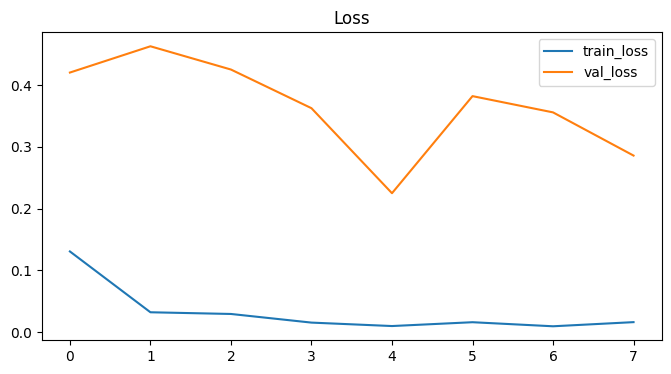

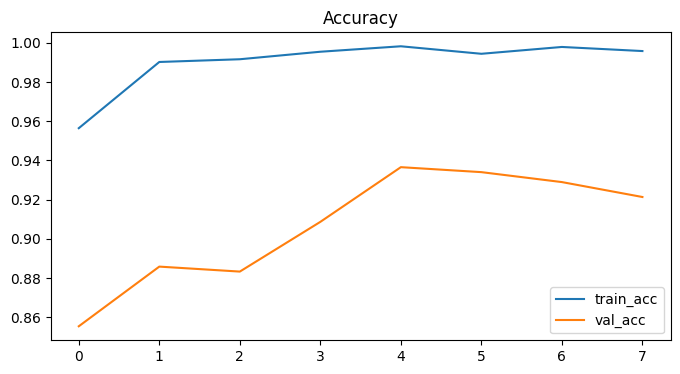

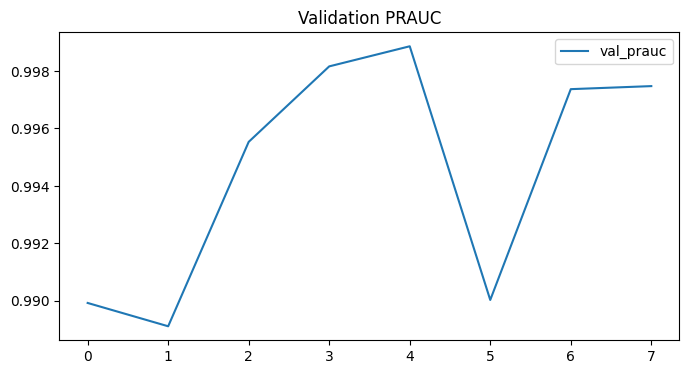

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["val_prauc"], label="val_prauc")
plt.legend()
plt.title("Validation PRAUC")
plt.show()